# Thực nghiệm so sánh Bloom Filter và Counting Bloom Filter

Notebook này cài đặt từ đầu **Bloom Filter (BF)** và **Counting Bloom Filter (CBF)**, rồi chạy 4 thực nghiệm định lượng phục vụ báo cáo *"So sánh Bloom Filter và Counting Bloom Filter trong bài toán lọc dữ liệu tốc độ cao"* (`report.tex`):

| Thực nghiệm | Câu hỏi | Giả thuyết |
|---|---|---|
| **E1** | FPR thực nghiệm có bám công thức lý thuyết? Thông lượng insert/query/delete? | H1, H3 |
| **E2** | FPR theo số hàm băm $k$: cực tiểu có đúng tại $k^*=(m/n)\ln 2$? | H4 |
| **E3** | Cùng ngân sách **byte**, BF hay CBF chính xác hơn? | H2 |
| **E4** | Xóa phần tử bị nhận nhầm (false positive) gây false negative ra sao? | Không áp dụng |

**Yêu cầu gói:** `pip install mmh3 bitarray numpy pandas matplotlib jinja2`

> Notebook **tự chứa** và là **nguồn duy nhất** của thực nghiệm: chạy toàn bộ notebook sẽ tái sinh `fig/*.png`, `tab/*.tex` (bảng + macro số liệu) và `results.json` mà `report.tex` nhúng vào. Khóa sinh tất định nên FPR tái lập được 100%; số đo thông lượng thay đổi nhẹ theo máy.

## 1. Tóm tắt lý thuyết

- **BF** (Bloom, 1970): mảng $m$ bit, $k$ hàm băm. Insert bật bit, Query kiểm tra đủ $k$ bit. Không false negative, không xóa được.
- **CBF** (Fan *et al.*, 2000): thay bit bằng counter $b$ bit (thường $b=4$, bão hòa ở 15) → hỗ trợ xóa khi caller chỉ xóa khóa chắc chắn đã chèn. Xóa khóa vắng mặt hoặc mất thông tin do counter bão hòa có thể sinh false negative.

Các công thức dùng để đối chiếu:

$$p \approx \left(1-e^{-kn/m}\right)^k, \qquad k^* = \frac{m}{n}\ln 2, \qquad m = -\frac{n\ln p}{(\ln 2)^2}$$

Số phần tử băm vào một counter $\approx$ Poisson$(\lambda{=}\ln 2)$ ở cấu hình tối ưu, nên $\Pr[\text{counter} = 16] \approx 6{.}78\times 10^{-17}$. Vì vậy, 4 bit/counter thường là đủ (Fan *et al.* 2000). Với counter bão hòa, phần tăng vượt 15 bị mất; nếu sau đó vẫn giảm như counter thường thì có thể xuất hiện false negative. Một chính sách khác là giữ counter bão hòa ở 15 vĩnh viễn, tránh lỗi này nhưng tạo false positive dai dẳng.

**Lưu ý then chốt:** với *cùng* $m$, $k$ và cùng bộ hàm băm, CBF (chỉ chèn) trả lời truy vấn **giống hệt** BF từng khóa; khác biệt thật sự nằm ở bộ nhớ và khả năng xóa.

In [1]:
import math
import os
import time

import mmh3                      # MurmurHash3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bitarray import bitarray

os.makedirs("fig", exist_ok=True)   # hinh cho report.tex
os.makedirs("tab", exist_ok=True)   # bang + macro so lieu cho report.tex
T0 = time.perf_counter()            # tinh tong thoi gian thuc nghiem

# ---- bang mau nhat quan, than thien voi nguoi mu mau ----
INK, SEC, MUT = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
C_BF, C_CBF4, C_CBF8 = "#2a78d6", "#eb6834", "#1baf7a"   # mau theo cau truc
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10.5, "font.family": "DejaVu Sans",
    "axes.edgecolor": AXIS, "axes.labelcolor": SEC, "text.color": INK,
    "xtick.color": MUT, "ytick.color": MUT,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "legend.frameon": False,
    "axes.spines.top": False, "axes.spines.right": False,
})


def optimal_k(m: int, n: int) -> int:
    """So ham bam toi uu k = (m/n) ln 2 (lam tron, toi thieu 1)."""
    return max(1, int(round((m / n) * math.log(2))))


def theoretical_fpr(m: int, n: int, k: int) -> float:
    """FPR ly thuyet p = (1 - e^{-kn/m})^k."""
    return (1.0 - math.exp(-k * n / m)) ** k


def _positions(key: str, k: int, m: int):
    """k vi tri bang double hashing Kirsch-Mitzenmacher tu 2 seed MurmurHash3."""
    h1 = mmh3.hash(key, 0, signed=False)
    h2 = mmh3.hash(key, 1, signed=False) | 1   # tranh h2 = 0 (chu ky suy bien)
    for i in range(k):
        yield (h1 + i * h2) % m


class BloomFilter:
    def __init__(self, m: int, k: int):
        self.m, self.k = m, k
        self.bits = bitarray(m)
        self.bits.setall(0)

    def insert(self, key):
        for pos in _positions(key, self.k, self.m):
            self.bits[pos] = 1

    def query(self, key):
        return all(self.bits[pos] for pos in _positions(key, self.k, self.m))

    def fill_ratio(self):
        return self.bits.count() / self.m

    def memory_bytes(self):
        return (self.m + 7) // 8


class CountingBloomFilter8:
    """CBF voi counter 8-bit dung nghia (0..255), 1 counter/byte."""
    MAX = 255

    def __init__(self, m: int, k: int):
        self.m, self.k = m, k
        self.counts = bytearray(m)

    def insert(self, key):
        for pos in _positions(key, self.k, self.m):
            if self.counts[pos] < self.MAX:
                self.counts[pos] += 1

    def query(self, key):
        return all(self.counts[pos] > 0 for pos in _positions(key, self.k, self.m))

    def delete(self, key):
        """Xoa khoa ma caller BIET da chen; CBF khong tu xac minh membership."""
        for pos in _positions(key, self.k, self.m):
            if self.counts[pos] > 0:
                self.counts[pos] -= 1
        return True

    def delete_if_present(self, key):
        """Guard minh hoa: query am thi chan; false positive van co the bi xoa sai."""
        if not self.query(key):
            return False
        return self.delete(key)

    def max_count(self):
        return max(self.counts, default=0)

    def memory_bytes(self):
        return self.m


class CountingBloomFilter4:
    """CBF 4-bit dung nghia: 2 counter/byte (nibble packing) -> dung 4x BF."""
    MAX = 15

    def __init__(self, m: int, k: int):
        self.m, self.k = m, k
        self.buf = bytearray((m + 1) // 2)

    def _get(self, i):
        b = self.buf[i >> 1]
        return (b >> 4) if (i & 1) else (b & 0x0F)

    def _set(self, i, v):
        j = i >> 1
        if i & 1:
            self.buf[j] = (self.buf[j] & 0x0F) | (v << 4)
        else:
            self.buf[j] = (self.buf[j] & 0xF0) | v

    def insert(self, key):
        for pos in _positions(key, self.k, self.m):
            v = self._get(pos)
            if v < self.MAX:
                self._set(pos, v + 1)

    def query(self, key):
        return all(self._get(pos) > 0 for pos in _positions(key, self.k, self.m))

    def delete(self, key):
        """Xoa khoa ma caller BIET da chen; CBF khong tu xac minh membership."""
        for pos in _positions(key, self.k, self.m):
            v = self._get(pos)
            if v > 0:
                self._set(pos, v - 1)
        return True

    def delete_if_present(self, key):
        """Guard minh hoa: query am thi chan; false positive van co the bi xoa sai."""
        if not self.query(key):
            return False
        return self.delete(key)

    def max_count(self):
        return max((max(b & 0x0F, b >> 4) for b in self.buf), default=0)

    def memory_bytes(self):
        return (self.m + 1) // 2

print("Đã định nghĩa BloomFilter, CountingBloomFilter4 (4-bit packed), CountingBloomFilter8 (8-bit).")

Đã định nghĩa BloomFilter, CountingBloomFilter4 (4-bit packed), CountingBloomFilter8 (8-bit).


## 2. Dữ liệu và hàm đo

Khóa sinh **tất định** (`P000000000…` cho tập đã chèn, `A000000000…` cho tập vắng mặt) để kết quả FPR tái lập được. FPR đo bằng tỉ lệ khóa vắng mặt bị trả lời "có" và kèm khoảng tin cậy Wilson 95%. Thông lượng đo bằng `time.perf_counter`; mỗi phép đo lặp 5 lượt trên trạng thái hợp lệ, báo median và IQR. Insert/delete dùng filter mới ở mỗi lượt để không đo trên cấu trúc đã bị biến đổi từ lượt trước.

In [2]:
N = 100_000
RATIOS = (4, 6, 8, 10, 12, 16)
PRESENT = [f"P{i:09d}" for i in range(N)]   # khoa se duoc chen
ABSENT  = [f"A{i:09d}" for i in range(N)]   # khoa chua tung chen


BENCH_REPEATS = 5


def timed_once(fn, keys):
    """Mot phep do throughput tren toan bo `keys`."""
    t0 = time.perf_counter()
    for key in keys:
        fn(key)
    return len(keys) / (time.perf_counter() - t0)


def summarize_rates(rates):
    """Tra median, Q1, Q3 cua throughput."""
    return tuple(float(x) for x in (np.median(rates), np.percentile(rates, 25),
                                      np.percentile(rates, 75)))


def benchmark_query(fn, keys, repeat=BENCH_REPEATS):
    return summarize_rates([timed_once(fn, keys) for _ in range(repeat)])


def benchmark_insert(cls, m, k, keys, repeat=BENCH_REPEATS):
    rates, last_filter = [], None
    for _ in range(repeat):
        last_filter = cls(m, k)
        rates.append(timed_once(last_filter.insert, keys))
    return summarize_rates(rates), last_filter


def benchmark_delete(cls, m, k, keys, repeat=BENCH_REPEATS):
    rates = []
    for _ in range(repeat):
        f = cls(m, k)
        for key in keys:
            f.insert(key)
        rates.append(timed_once(f.delete, keys))
    return summarize_rates(rates)


def measure_fpr(f, absent_keys):
    return sum(1 for key in absent_keys if f.query(key)) / len(absent_keys)


def wilson_interval(successes, total, z=1.96):
    """Khoang tin cay Wilson hai phia cho ti le nhi thuc."""
    p = successes / total
    den = 1 + z * z / total
    center = (p + z * z / (2 * total)) / den
    half = z * math.sqrt(p * (1 - p) / total + z * z / (4 * total * total)) / den
    return center - half, center + half


# --- smoke test nhanh ---
_bf, _c4 = BloomFilter(80_000, 6), CountingBloomFilter4(80_000, 6)
for x in PRESENT[:10_000]:
    _bf.insert(x); _c4.insert(x)
assert all(_bf.query(x) for x in PRESENT[:10_000]), "BF khong duoc phep co false negative"
assert all(_c4.query(x) for x in PRESENT[:10_000])
assert measure_fpr(_bf, ABSENT[:10_000]) == measure_fpr(_c4, ABSENT[:10_000]), \
    "cung m, k, cung ham bam -> BF va CBF phai tra loi giong het nhau"
for x in PRESENT[:10_000]:
    _c4.delete(x)
assert sum(_c4.query(x) for x in PRESENT[:10_000]) == 0, "xoa het thi CBF phai rong"
print("Smoke test OK: không FN khi chỉ chèn; BF ≡ CBF cùng cấu hình; delete hoạt động đúng.")

Smoke test OK: không FN khi chỉ chèn; BF ≡ CBF cùng cấu hình; delete hoạt động đúng.


## 3. E1: FPR và thông lượng theo $m/n$ (H1, H3)

Với mỗi tỉ lệ $m/n$, chèn $n$ khóa vào cả ba cấu trúc với $k=\mathrm{round}((m/n)\ln 2)$, đo FPR trên $n$ khóa vắng mặt và thông lượng từng thao tác. Câu trả lời của BF và CBF được **assert trùng nhau trên từng khóa**, qua đó minh họa rằng CBF không "chính xác hơn" BF.

In [3]:
rows = []
for r in RATIOS:
    m, k = r * N, optimal_k(r * N, N)
    (ins_bf, ins_bf_q1, ins_bf_q3), bf = benchmark_insert(BloomFilter, m, k, PRESENT)
    (ins_c4, ins_c4_q1, ins_c4_q3), c4 = benchmark_insert(CountingBloomFilter4, m, k, PRESENT)
    (ins_c8, ins_c8_q1, ins_c8_q3), c8 = benchmark_insert(CountingBloomFilter8, m, k, PRESENT)

    fp_hits = sum(1 for x in ABSENT if bf.query(x))
    fpr_bf = fp_hits / len(ABSENT)
    fpr_ci_low, fpr_ci_high = wilson_interval(fp_hits, len(ABSENT))
    # cung vi tri bam -> cau tra loi phai trung nhau TUNG khoa (khong chi FPR gop)
    assert all(bf.query(x) == c4.query(x) == c8.query(x) for x in ABSENT)

    qmiss_bf, qmiss_bf_q1, qmiss_bf_q3 = benchmark_query(bf.query, ABSENT)
    qmiss_c4, qmiss_c4_q1, qmiss_c4_q3 = benchmark_query(c4.query, ABSENT)
    qmiss_c8, qmiss_c8_q1, qmiss_c8_q3 = benchmark_query(c8.query, ABSENT)
    qhit_bf, qhit_bf_q1, qhit_bf_q3 = benchmark_query(bf.query, PRESENT)
    qhit_c4, qhit_c4_q1, qhit_c4_q3 = benchmark_query(c4.query, PRESENT)
    del_c4, del_c4_q1, del_c4_q3 = benchmark_delete(CountingBloomFilter4, m, k, PRESENT)
    del_c8, del_c8_q1, del_c8_q3 = benchmark_delete(CountingBloomFilter8, m, k, PRESENT)
    for x in PRESENT:
        c4.delete(x)
    leftover = sum(1 for x in PRESENT if c4.query(x))   # sau khi xoa dung het -> ky vong 0

    rows.append(dict(ratio=r, k=k, fpr_theory=theoretical_fpr(m, N, k),
                     fp_hits=fp_hits, fpr_emp=fpr_bf,
                     fpr_ci_low=fpr_ci_low, fpr_ci_high=fpr_ci_high,
                     fill_bf=bf.fill_ratio(),
                     fill_theory=1 - math.exp(-k * N / m),
                     mem_bf=bf.memory_bytes(), mem_c4=c4.memory_bytes(), mem_c8=c8.memory_bytes(),
                     ins_bf=ins_bf, ins_c4=ins_c4, ins_c8=ins_c8,
                     ins_bf_q1=ins_bf_q1, ins_bf_q3=ins_bf_q3,
                     ins_c4_q1=ins_c4_q1, ins_c4_q3=ins_c4_q3,
                     ins_c8_q1=ins_c8_q1, ins_c8_q3=ins_c8_q3,
                     qmiss_bf=qmiss_bf, qmiss_c4=qmiss_c4, qmiss_c8=qmiss_c8,
                     qmiss_bf_q1=qmiss_bf_q1, qmiss_bf_q3=qmiss_bf_q3,
                     qmiss_c4_q1=qmiss_c4_q1, qmiss_c4_q3=qmiss_c4_q3,
                     qmiss_c8_q1=qmiss_c8_q1, qmiss_c8_q3=qmiss_c8_q3,
                     qhit_bf=qhit_bf, qhit_c4=qhit_c4,
                     qhit_bf_q1=qhit_bf_q1, qhit_bf_q3=qhit_bf_q3,
                     qhit_c4_q1=qhit_c4_q1, qhit_c4_q3=qhit_c4_q3,
                     del_c4=del_c4, del_c8=del_c8, leftover=leftover))
    rows[-1].update(del_c4_q1=del_c4_q1, del_c4_q3=del_c4_q3,
                    del_c8_q1=del_c8_q1, del_c8_q3=del_c8_q3)
    print(f"m/n={r:>2} k={k:>2}: FPR lý thuyết={rows[-1]['fpr_theory']:.5f}, "
          f"đo được={fpr_bf:.5f} (KTC 95% {fpr_ci_low:.5f}–{fpr_ci_high:.5f}), "
          f"còn sót sau xóa đúng hết={leftover}")

e1 = pd.DataFrame(rows)
display(e1[["ratio", "k", "fpr_theory", "fpr_emp", "fpr_ci_low",
            "fpr_ci_high", "fill_bf", "fill_theory"]]
        .rename(columns={"ratio": "m/n", "fpr_theory": "FPR lý thuyết",
                         "fpr_emp": "FPR đo được (BF ≡ CBF)",
                         "fpr_ci_low": "KTC 95% dưới", "fpr_ci_high": "KTC 95% trên",
                         "fill_bf": "tỉ lệ bit 1 (đo)", "fill_theory": "tỉ lệ bit 1 (lt)"})
        .style.format({"FPR lý thuyết": "{:.5f}", "FPR đo được (BF ≡ CBF)": "{:.5f}",
                       "KTC 95% dưới": "{:.5f}", "KTC 95% trên": "{:.5f}",
                       "tỉ lệ bit 1 (đo)": "{:.3f}", "tỉ lệ bit 1 (lt)": "{:.3f}"}))

m/n= 4 k= 3: FPR lý thuyết=0.14689, đo được=0.14933 (KTC 95% 0.14713–0.15155), còn sót sau xóa đúng hết=0


m/n= 6 k= 4: FPR lý thuyết=0.05606, đo được=0.05650 (KTC 95% 0.05509–0.05795), còn sót sau xóa đúng hết=0


m/n= 8 k= 6: FPR lý thuyết=0.02158, đo được=0.02164 (KTC 95% 0.02076–0.02256), còn sót sau xóa đúng hết=0


m/n=10 k= 7: FPR lý thuyết=0.00819, đo được=0.00819 (KTC 95% 0.00765–0.00877), còn sót sau xóa đúng hết=0


m/n=12 k= 8: FPR lý thuyết=0.00314, đo được=0.00334 (KTC 95% 0.00300–0.00372), còn sót sau xóa đúng hết=0


m/n=16 k=11: FPR lý thuyết=0.00046, đo được=0.00043 (KTC 95% 0.00032–0.00058), còn sót sau xóa đúng hết=0


,m/n,k,FPR lý thuyết,FPR đo được (BF ≡ CBF),KTC 95% dưới,KTC 95% trên,tỉ lệ bit 1 (đo),tỉ lệ bit 1 (lt)
0,4,3,0.14689,0.14933,0.14713,0.15155,0.529,0.528
1,6,4,0.05606,0.05650,0.05509,0.05795,0.487,0.487
2,8,6,0.02158,0.02164,0.02076,0.02256,0.528,0.528
3,10,7,0.00819,0.00819,0.00765,0.00877,0.503,0.503
4,12,8,0.00314,0.00334,0.00300,0.00372,0.487,0.487
5,16,11,0.00046,0.00043,0.00032,0.00058,0.497,0.497


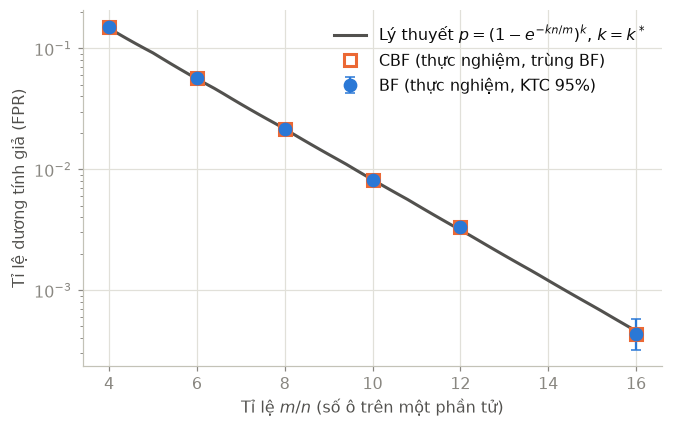

In [4]:
fine = np.arange(4, 16.01, 0.2)
th = [theoretical_fpr(int(x * N), N, optimal_k(int(x * N), N)) for x in fine]
fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.plot(fine, th, "-", color=SEC, lw=2, label="Lý thuyết $p=(1-e^{-kn/m})^k$, $k=k^*$")
fpr_yerr = np.vstack([e1["fpr_emp"] - e1["fpr_ci_low"],
                       e1["fpr_ci_high"] - e1["fpr_emp"]])
ax.errorbar(e1["ratio"], e1["fpr_emp"], yerr=fpr_yerr, fmt="o",
            color=C_BF, ms=8, capsize=3, label="BF (thực nghiệm, KTC 95%)")
ax.plot(e1["ratio"], e1["fpr_emp"], "s", color=C_CBF4, ms=8, mfc="none", mew=2,
        label="CBF (thực nghiệm, trùng BF)")
ax.set_yscale("log")
ax.set_xlabel("Tỉ lệ $m/n$ (số ô trên một phần tử)")
ax.set_ylabel("Tỉ lệ dương tính giả (FPR)")
ax.legend()
fig.savefig("fig/fpr_vs_mn.png", dpi=200, bbox_inches="tight")
plt.show()

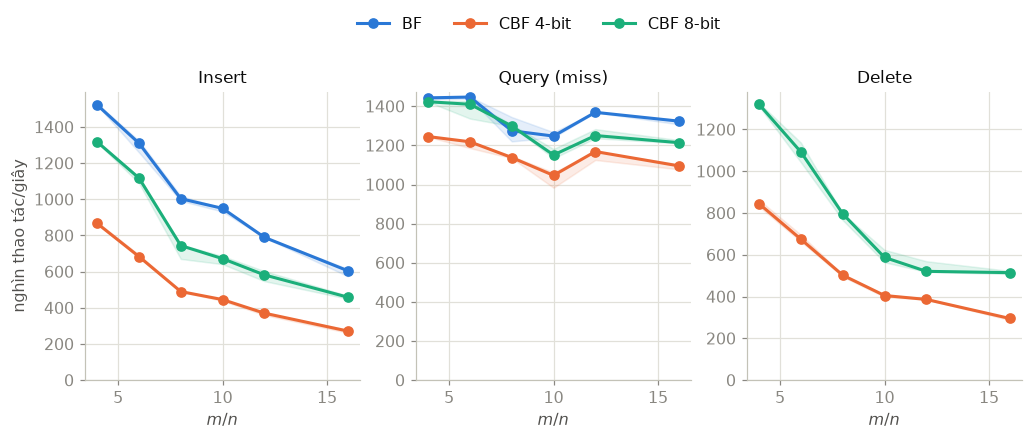

Tại m/n=10: insert BF nhanh gấp 2.13 lần CBF 4-bit; query(miss) gấp 1.19 lần; delete CBF 4-bit chỉ đạt 405 nghìn thao tác/giây.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), sharex=True)
panels = [("Insert", [("BF", "ins_bf", C_BF), ("CBF 4-bit", "ins_c4", C_CBF4),
                      ("CBF 8-bit", "ins_c8", C_CBF8)]),
          ("Query (miss)", [("BF", "qmiss_bf", C_BF), ("CBF 4-bit", "qmiss_c4", C_CBF4),
                            ("CBF 8-bit", "qmiss_c8", C_CBF8)]),
          ("Delete", [("CBF 4-bit", "del_c4", C_CBF4), ("CBF 8-bit", "del_c8", C_CBF8)])]
for ax, (title, series) in zip(axes, panels):
    for label, field, color in series:
        ax.plot(e1["ratio"], e1[field] / 1e3, "o-", color=color, lw=2, ms=6, label=label)
        ax.fill_between(e1["ratio"], e1[field + "_q1"] / 1e3,
                        e1[field + "_q3"] / 1e3, color=color, alpha=0.12)
    ax.set_title(title, color=INK, fontsize=11)
    ax.set_xlabel("$m/n$")
    ax.set_ylim(bottom=0)
axes[0].set_ylabel("nghìn thao tác/giây")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.12))
fig.savefig("fig/throughput.png", dpi=200, bbox_inches="tight")
plt.show()

r10 = e1.set_index("ratio").loc[10]
print(f"Tại m/n=10: insert BF nhanh gấp {r10.ins_bf / r10.ins_c4:.2f} lần CBF 4-bit; "
      f"query(miss) gấp {r10.qmiss_bf / r10.qmiss_c4:.2f} lần; "
      f"delete CBF 4-bit chỉ đạt {r10.del_c4 / 1e3:.0f} nghìn thao tác/giây.")

**Nhận xét E1.** FPR đo được gần lý thuyết trên toàn dải và được trình bày cùng KTC Wilson 95%; BF và hai CBF trùng *từng khóa* vì dùng cùng vị trí băm. Trong **cài đặt Python này**, BF có median throughput cao hơn CBF packed; CBF 8-bit thường nhanh hơn CBF 4-bit packed do không tách nibble. Đây là kết quả phụ thuộc hiện thực (`bitarray`, `bytearray`, vòng lặp Python), không phải bằng chứng rằng mọi cài đặt BF luôn nhanh hơn mọi CBF. Delete được đo theo contract chuẩn: caller biết khóa đã chèn, không có lượt query bảo vệ đi kèm. Dải tô trên hình là IQR của 5 lượt đo.

## 4. E2: FPR theo số hàm băm $k$ (H4)

Cố định $m/n=10$, quét $k$ từ 1 đến 12. Kỳ vọng cực tiểu tại $k^*=(m/n)\ln 2\approx 7$: $k$ nhỏ → mỗi phép thử dễ trùng; $k$ lớn → mảng bit bị lấp đầy.

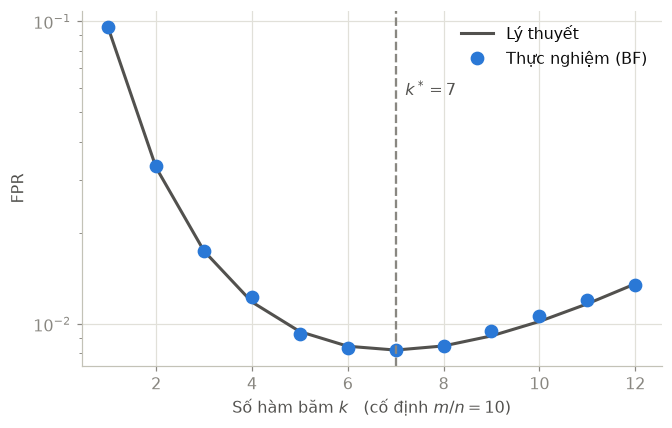

FPR nhỏ nhất đo được tại k=7 (lý thuyết k*=7): 0.00819


In [6]:
m10 = 10 * N
ks = list(range(1, 13))
fpr_th_k, fpr_emp_k = [], []
for k in ks:
    bf = BloomFilter(m10, k)
    for x in PRESENT:
        bf.insert(x)
    fpr_th_k.append(theoretical_fpr(m10, N, k))
    fpr_emp_k.append(measure_fpr(bf, ABSENT))

k_opt = optimal_k(m10, N)
fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.plot(ks, fpr_th_k, "-", color=SEC, lw=2, label="Lý thuyết")
ax.plot(ks, fpr_emp_k, "o", color=C_BF, ms=8, label="Thực nghiệm (BF)")
ax.axvline(k_opt, color=MUT, ls="--", lw=1.5)
ax.annotate(f"$k^*={k_opt}$", xy=(k_opt + 0.2, max(fpr_th_k) * 0.6), color=SEC)
ax.set_yscale("log")
ax.set_xlabel("Số hàm băm $k$   (cố định $m/n=10$)")
ax.set_ylabel("FPR")
ax.legend()
fig.savefig("fig/fpr_vs_k.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"FPR nhỏ nhất đo được tại k={ks[int(np.argmin(fpr_emp_k))]} "
      f"(lý thuyết k*={k_opt}): {min(fpr_emp_k):.5f}")

## 5. E3: Đánh đổi FPR khi cố định payload bộ nhớ (H2)

Đây là phép so công bằng khi bộ nhớ là ràng buộc cứng: cùng $B$ byte thì BF có $8B$ ô, CBF 4-bit có $2B$ ô, CBF 8-bit có $B$ ô (mỗi cấu trúc dùng $k$ tối ưu của riêng nó). Chọn $B$ = bộ nhớ của BF tại $m/n=10$.

,cấu_trúc,số_ô,k,mem_byte,FPR_lý_thuyết,FP,FPR_đo_được,KTC95_dưới,KTC95_trên
0,BF,"1,000,000",7,"125,000",0.0082,819,0.0082,0.0076,0.0088
1,CBF 4-bit,"250,000",2,"125,000",0.3032,30085,0.3009,0.2980,0.3037
2,CBF 8-bit,"125,000",1,"125,000",0.5507,54945,0.5494,0.5464,0.5525


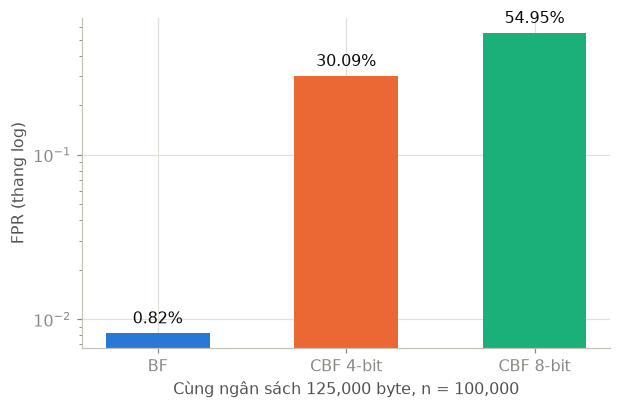

In [7]:
budget = 10 * N // 8          # 125 000 byte
cfgs = []
for name, cls, cells_ in (("BF", BloomFilter, budget * 8),
                          ("CBF 4-bit", CountingBloomFilter4, budget * 2),
                          ("CBF 8-bit", CountingBloomFilter8, budget)):
    k = optimal_k(cells_, N)
    f = cls(cells_, k)
    for x in PRESENT:
        f.insert(x)
    fp_hits = sum(1 for x in ABSENT if f.query(x))
    ci_low, ci_high = wilson_interval(fp_hits, len(ABSENT))
    cfgs.append(dict(cấu_trúc=name, số_ô=cells_, k=k, mem_byte=f.memory_bytes(),
                     FPR_lý_thuyết=theoretical_fpr(cells_, N, k),
                     FP=fp_hits, FPR_đo_được=fp_hits / len(ABSENT),
                     KTC95_dưới=ci_low, KTC95_trên=ci_high))
e3 = pd.DataFrame(cfgs)
display(e3.style.format({"FPR_lý_thuyết": "{:.4f}", "FPR_đo_được": "{:.4f}",
                         "KTC95_dưới": "{:.4f}", "KTC95_trên": "{:.4f}",
                         "số_ô": "{:,}", "mem_byte": "{:,}"}))

fig, ax = plt.subplots(figsize=(6.2, 3.9))
bars = ax.bar(e3["cấu_trúc"], e3["FPR_đo_được"], color=[C_BF, C_CBF4, C_CBF8], width=0.55)
for bar, v in zip(bars, e3["FPR_đo_được"]):
    ax.text(bar.get_x() + bar.get_width() / 2, v * 1.15, f"{100 * v:.2f}%",
            ha="center", color=INK)
ax.set_yscale("log")
ax.set_ylabel("FPR (thang log)")
ax.set_xlabel(f"Cùng ngân sách {budget:,} byte, n = {N:,}")
fig.savefig("fig/equal_budget.png", dpi=200, bbox_inches="tight")
plt.show()

**Nhận xét E3.** Với cùng dung lượng **payload** của mảng backing, CBF 4-bit packed có ít ô hơn BF 4 lần nên FPR cao hơn rõ rệt (H2 ✓). Đây là phép đo đánh đổi dung lượng–FPR, không phải so sánh hai cấu trúc tương đương chức năng: BF không hỗ trợ delete. Hệ số 4×/8× xuất phát trực tiếp từ cách biểu diễn; phép đo không bao gồm object header, allocator hay RSS của tiến trình.

## 6. E4: Contract của delete và stress test xóa sai

CBF chỉ đảm bảo không false negative khi caller tuân thủ contract: chỉ xóa khóa chắc chắn đã chèn và counter không mất thông tin do overflow. E4 gồm hai phần: (1) xóa đúng 20.000 khóa rồi kiểm tra toàn bộ khóa thật còn lại; (2) stress test có chủ đích, trong đó hệ thống nhầm câu trả lời "có" là bằng chứng membership và xóa các khóa chưa từng chèn. `delete_if_present` chỉ chặn query âm; false positive vẫn có thể lọt qua. Kết quả phần (2) là hậu quả có điều kiện của workload xóa sai, không phải FNR mặc định của CBF.

In [8]:
m8, k8 = 8 * N, optimal_k(8 * N, N)
cbf = CountingBloomFilter4(m8, k8)
for x in PRESENT:
    cbf.insert(x)

max_counter_before = cbf.max_count()

valid_delete_n = 20_000
cbf_valid = CountingBloomFilter4(m8, k8)
for x in PRESENT:
    cbf_valid.insert(x)
for x in PRESENT[:valid_delete_n]:
    cbf_valid.delete(x)
valid_remaining_fn = sum(1 for x in PRESENT[valid_delete_n:] if not cbf_valid.query(x))

fp_keys = [x for x in ABSENT if cbf.query(x)]
performed = sum(1 for x in fp_keys if cbf.delete_if_present(x))
false_neg = sum(1 for x in PRESENT if not cbf.query(x))

print(f"Cấu hình m/n=8, k={k8}, n={N:,}")
print(f"Counter lớn nhất sau insert                     : {max_counter_before}")
print(f"FN trong {N-valid_delete_n:,} khóa còn lại sau xóa đúng: {valid_remaining_fn:,}")
print(f"Khóa vắng mặt bị báo nhầm 'có' (false positive): {len(fp_keys):,}")
print(f"Lần xóa sai lọt qua query guard              : {performed:,}")
print(f"Phần tử thật bị mất (FALSE NEGATIVE)           : {false_neg:,} "
      f"({100 * false_neg / N:.3f}% của {N:,})")
print(f"\n=> Stress test: {len(fp_keys):,} yêu cầu xóa sai làm mất {false_neg:,} phần tử thật.")
print("   Đây là vi phạm contract delete, không phải FNR mặc định của CBF.")

Cấu hình m/n=8, k=6, n=100,000
Counter lớn nhất sau insert                     : 8
FN trong 80,000 khóa còn lại sau xóa đúng: 0
Khóa vắng mặt bị báo nhầm 'có' (false positive): 2,164
Lần xóa sai lọt qua query guard              : 2,041
Phần tử thật bị mất (FALSE NEGATIVE)           : 8,063 (8.063% của 100,000)

=> Stress test: 2,164 yêu cầu xóa sai làm mất 8,063 phần tử thật.
   Đây là vi phạm contract delete, không phải FNR mặc định của CBF.


## 7. Kết luận

| Giả thuyết | Kết quả |
|---|---|
| **H1:** FPR thực nghiệm trùng giữa BF/CBF và bám lý thuyết | ✓ (trùng *từng khóa*, sai lệch với lý thuyết trong biên độ thống kê) |
| **H2:** Payload CBF 4-bit packed bằng $4\times$ BF (8-bit: $8\times$) | ✓ theo cách biểu diễn; không tính object header/allocator/RSS |
| **H3:** BF nhanh hơn CBF trong cài đặt Python đang xét | ✓ với median 5 lượt; IQR được lưu và vẽ, nhưng không tổng quát hóa sang mọi ngôn ngữ/hiện thực |
| **H4:** FPR giảm mũ theo $m/n$, cực tiểu theo $k$ tại $k^*$ | ✓ ($k^*=7$ tại $m/n=10$) |

**Khuyến nghị:** dùng **BF** cho tập gần như tĩnh hoặc rebuild được định kỳ. Dùng **CBF 4-bit** khi cần delete/counting và hệ thống có thể bảo đảm chỉ xóa khóa đã chèn; theo dõi overflow hoặc rebuild từ nguồn dữ liệu chuẩn khi contract này có thể bị vi phạm. Khi cần xóa với FPR mục tiêu $<3\%$, cân nhắc **Cuckoo Filter**. Chi tiết lý thuyết, trích dẫn và thảo luận đầy đủ: xem `report.pdf`.

## 8. Phụ lục: Xuất số liệu cho báo cáo LaTeX

Cell dưới ghi toàn bộ sản phẩm số liệu mà `report.tex` nhúng: các mảnh bảng `booktabs` trong `tab/`, macro số liệu `tab/numbers.tex` (để lời văn của báo cáo không phải chép số tay), và `results.json` (bản ghi đầy đủ). Bốn hình trong `fig/` đã được lưu ngay tại cell vẽ của từng thực nghiệm. Sau khi chạy notebook, biên dịch lại báo cáo bằng `pdflatex report.tex` (2 lượt).

In [9]:
import importlib.metadata
import json
import platform


def sep(x):
    """So nguyen kieu SI: dau cach manh \\, lam phan cach hang nghin (LaTeX)."""
    return f"{x:,.0f}".replace(",", "\\,")


def fmt_pct(x):
    return f"{100 * x:.3f}\\%" if x < 0.10 else f"{100 * x:.1f}\\%"


def pct(x, d=2):
    return f"{100 * x:.{d}f}\\%"


def kops(x):
    return sep(x / 1e3)


# ---- tab/fpr.tex : E1, FPR ly thuyet vs thuc nghiem ----
with open("tab/fpr.tex", "w") as f:
    f.write("\\begin{tabular}{@{}rrrrlrr@{}}\n\\toprule\n"
            "$m/n$ & $k$ & FPR lý thuyết & FPR đo (BF $\\equiv$ CBF) & KTC 95\\% & "
            "Tỉ lệ bit 1 (đo) & (lý thuyết)\\\\\n\\midrule\n")
    for r in e1.itertuples():
        f.write(f"{r.ratio} & {r.k} & {fmt_pct(r.fpr_theory)} & "
                f"{fmt_pct(r.fpr_emp)} & [{fmt_pct(r.fpr_ci_low)}, {fmt_pct(r.fpr_ci_high)}] & "
                f"{r.fill_bf:.3f} & {r.fill_theory:.3f}\\\\\n")
    f.write("\\bottomrule\n\\end{tabular}\n")

# ---- tab/throughput.tex : E1, thong luong ----
with open("tab/throughput.tex", "w") as f:
    f.write("\\begin{tabular}{@{}rrrrrrrr@{}}\n\\toprule\n"
            "$m/n$ & $k$ & \\multicolumn{2}{c}{Insert} & "
            "\\multicolumn{2}{c}{Query (miss)} & "
            "\\multicolumn{2}{c}{Query (hit) / Delete}\\\\\n"
            "\\cmidrule(lr){3-4}\\cmidrule(lr){5-6}\\cmidrule(l){7-8}\n"
            " & & BF & CBF4 & BF & CBF4 & BF hit & CBF4 del\\\\\n\\midrule\n")
    for r in e1.itertuples():
        f.write(f"{r.ratio} & {r.k} & {kops(r.ins_bf)} & {kops(r.ins_c4)} & "
                f"{kops(r.qmiss_bf)} & {kops(r.qmiss_c4)} & "
                f"{kops(r.qhit_bf)} & {kops(r.del_c4)}\\\\\n")
    f.write("\\bottomrule\n\\end{tabular}\n")

# ---- tab/memory.tex : E1, bo nho ----
with open("tab/memory.tex", "w") as f:
    f.write("\\begin{tabular}{@{}rrrrrr@{}}\n\\toprule\n"
            "$m/n$ & $m$ (ô) & BF (byte) & CBF 4-bit (byte) & CBF 8-bit (byte) & "
            "CBF4/BF\\\\\n\\midrule\n")
    for r in e1.itertuples():
        f.write(f"{r.ratio} & {sep(r.ratio * N)} & {sep(r.mem_bf)} & "
                f"{sep(r.mem_c4)} & {sep(r.mem_c8)} & "
                f"{r.mem_c4 / r.mem_bf:.1f}$\\times$\\\\\n")
    f.write("\\bottomrule\n\\end{tabular}\n")

# ---- tab/equal_budget.tex : E3 ----
bits = {"BF": 1, "CBF 4-bit": 4, "CBF 8-bit": 8}
with open("tab/equal_budget.tex", "w") as f:
    f.write("\\begin{tabular}{@{}lrrrrr@{}}\n\\toprule\n"
            "Cấu trúc & Số ô & bit/ô & $k$ & FPR lý thuyết & FPR thực nghiệm\\\\\n"
            "\\midrule\n")
    for _, c in e3.iterrows():
        f.write(f"{c['cấu_trúc']} & {sep(c['số_ô'])} & {bits[c['cấu_trúc']]} & "
                f"{c['k']} & {fmt_pct(c['FPR_lý_thuyết'])} & "
                f"{fmt_pct(c['FPR_đo_được'])}\\\\\n")
    f.write("\\bottomrule\n\\end{tabular}\n")

# ---- tab/false_neg.tex : E4 ----
with open("tab/false_neg.tex", "w") as f:
    f.write("\\begin{tabular}{@{}lr@{}}\n\\toprule\nĐại lượng & Giá trị\\\\\n\\midrule\n"
            f"Cấu hình & $m/n={m8 // N}$, $k={k8}$, $n={sep(N)}$\\\\\n"
            f"Counter lớn nhất sau insert & {max_counter_before}\\\\\n"
            f"Xóa đúng / FN trong khóa thật còn lại & {sep(valid_delete_n)} / {sep(valid_remaining_fn)}\\\\\n"
            f"Khóa vắng mặt bị báo nhầm ``có'' (false positive) & {sep(len(fp_keys))}\\\\\n"
            f"Lần xóa sai lọt qua query guard & {sep(performed)}\\\\\n"
            f"Phần tử thật bị mất trong stress test & {sep(false_neg)}\\\\\n"
            f"Tỉ lệ false negative trong stress test & {fmt_pct(false_neg / N)}\\\\\n"
            "\\bottomrule\n\\end{tabular}\n")

# ---- tab/numbers.tex : macro so lieu cho loi van bao cao ----
cpu = platform.processor() or "unknown"
try:
    with open("/proc/cpuinfo") as f:
        for line in f:
            if line.startswith("model name"):
                cpu = line.split(":", 1)[1].strip()
                break
except OSError:
    pass
runtime = time.perf_counter() - T0
package_versions = {name: importlib.metadata.version(name)
                    for name in ("mmh3", "bitarray", "matplotlib", "numpy", "pandas")}
r8 = e1.set_index("ratio").loc[8]
r10 = e1.set_index("ratio").loc[10]
q = e3.set_index("cấu_trúc")
macros = {
    "NKeys": sep(N), "EnvPython": platform.python_version(), "EnvCPU": cpu,
    "EnvMmhThree": package_versions["mmh3"], "EnvBitarray": package_versions["bitarray"],
    "EnvMatplotlib": package_versions["matplotlib"], "EnvNumpy": package_versions["numpy"],
    "EnvPandas": package_versions["pandas"],
    "RuntimeSec": f"{runtime:.0f}", "BenchRepeats": str(BENCH_REPEATS),
    "FprThEight": pct(r8.fpr_theory), "FprEmpEight": pct(r8.fpr_emp),
    "FprThTen": pct(r10.fpr_theory), "FprEmpTen": pct(r10.fpr_emp),
    "FprCiLowTen": pct(r10.fpr_ci_low, 3), "FprCiHighTen": pct(r10.fpr_ci_high, 3),
    "KOptTen": str(int(r10.k)),
    "FillEmpTen": f"{r10.fill_bf:.3f}", "FillThTen": f"{r10.fill_theory:.3f}",
    "InsBFTen": kops(r10.ins_bf), "InsCBFTen": kops(r10.ins_c4),
    "QmissBFTen": kops(r10.qmiss_bf), "QmissCBFTen": kops(r10.qmiss_c4),
    "QhitBFTen": kops(r10.qhit_bf), "QhitCBFTen": kops(r10.qhit_c4),
    "DelCBFTen": kops(r10.del_c4),
    "InsRatioTen": f"{r10.ins_bf / r10.ins_c4:.2f}",
    "QmissRatioTen": f"{r10.qmiss_bf / r10.qmiss_c4:.2f}",
    "MemBFTen": sep(r10.mem_bf), "MemCBFFourTen": sep(r10.mem_c4),
    "MemCBFEightTen": sep(r10.mem_c8),
    "BudgetBytes": sep(budget),
    "EqFprBF": pct(q.loc["BF", "FPR_đo_được"]),
    "EqFprCBFFour": pct(q.loc["CBF 4-bit", "FPR_đo_được"], 1),
    "EqFprCBFEight": pct(q.loc["CBF 8-bit", "FPR_đo_được"], 1),
    "EqCellsBF": sep(q.loc["BF", "số_ô"]),
    "EqCellsCBFFour": sep(q.loc["CBF 4-bit", "số_ô"]),
    "EqCellsCBFEight": sep(q.loc["CBF 8-bit", "số_ô"]),
    "EqRatioFour": f"{q.loc['CBF 4-bit', 'FPR_đo_được'] / q.loc['BF', 'FPR_đo_được']:.0f}",
    "EqRatioEight": f"{q.loc['CBF 8-bit', 'FPR_đo_được'] / q.loc['BF', 'FPR_đo_được']:.0f}",
    "FnRatio": str(m8 // N), "FnK": str(k8),
    "FnFpDeleted": sep(len(fp_keys)), "FnPerformed": sep(performed),
    "FnCount": sep(false_neg), "FnRate": pct(false_neg / N),
    "FnMaxCounter": str(max_counter_before), "FnValidDeleted": sep(valid_delete_n),
    "FnValidRemaining": sep(N - valid_delete_n), "FnValidFalseNeg": sep(valid_remaining_fn),
}
with open("tab/numbers.tex", "w") as f:
    for name, val in macros.items():
        f.write(f"\\newcommand{{\\{name}}}{{{val}}}\n")

# ---- results.json : ban ghi day du ----
results = dict(
    n=N, ratios=list(RATIOS),
    e1=e1.to_dict("records"),
    e2=dict(ratio=10, m=m10, k_opt=k_opt,
            rows=[dict(k=k, fpr_theory=t, fpr_emp=e)
                  for k, t, e in zip(ks, fpr_th_k, fpr_emp_k)]),
    e3=dict(budget_bytes=budget, configs=e3.to_dict("records")),
    e4=dict(ratio=m8 // N, k=k8, n=N, max_counter_before=max_counter_before,
            valid_deletes=valid_delete_n, valid_remaining=N - valid_delete_n,
            valid_remaining_false_negatives=valid_remaining_fn,
            invalid_delete_candidates=len(fp_keys), invalid_deletes_performed=performed,
            stress_false_negatives=false_neg, stress_fn_rate=false_neg / N),
    benchmark=dict(repeats=BENCH_REPEATS, summary="median", dispersion="IQR"),
    env=dict(python=platform.python_version(), cpu=cpu, os=platform.platform(),
             packages=package_versions),
    runtime_seconds=round(runtime, 1),
)
with open("results.json", "w") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"Đã ghi {len(macros)} macro vào tab/numbers.tex; 5 bảng tab/*.tex; "
      f"results.json; 4 hình fig/*.png (tại các cell vẽ).")
print(f"Tổng thời gian thực nghiệm: {runtime:.0f} giây.")

Đã ghi 50 macro vào tab/numbers.tex; 5 bảng tab/*.tex; results.json; 4 hình fig/*.png (tại các cell vẽ).
Tổng thời gian thực nghiệm: 62 giây.
